In [1]:
# importing all required library
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# https://scikit-learn.org/stable/api/sklearn.preprocessing.html#module-sklearn.preprocessing

In [2]:
# load the clean data
data = pd.read_csv('cleaned_loan_data.csv')
data.head(4)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Approved,total_applicant_income
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,False,6091.0
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,True,3000.0
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,True,4941.0
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,True,6000.0


In [3]:
# lets drop : ApplicantIncome	CoapplicantIncome : 
# why ?? These information is available in total_applicant_income

final_df = data.drop(['ApplicantIncome', 'CoapplicantIncome'],axis=1)
final_df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status', 'Approved', 'total_applicant_income'],
      dtype='object')

In [5]:
# create some more feature
final_df['ratio_income_loan_req'] = round(final_df['LoanAmount'] / \
    final_df['total_applicant_income'],2)
# replace 3+ with 3

final_df['Dependents'] = final_df['Dependents'].replace(
    to_replace="3+", value='3')

final_df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Approved,total_applicant_income,ratio_income_loan_req
0,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,False,6091.0,0.02
1,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,True,3000.0,0.02


#### Encoding

As machines only understand 0's and 1's. We've to convert our categorical columns to 0's and 1's.

In [6]:
final_df['Gender'] = final_df['Gender'].map(
    {'Male': 1, 'Female': 0}).astype('int')
final_df['Married'] = final_df['Married'].map(
    {'Yes': 1, 'No': 0}).astype('int')
final_df['Education'] = final_df['Education'].map(
    {'Graduate': 1, 'Not Graduate': 0}).astype('int')
final_df['Self_Employed'] = final_df['Self_Employed'].map(
    {'Yes': 1, 'No': 0}).astype('int')
final_df['Property_Area'] = final_df['Property_Area'].map(
    {'Rural': 0, 'Semiurban': 2, 'Urban': 1}).astype('int')
final_df['Loan_Status'] = final_df['Loan_Status'].map(
    {'Y': 1, 'N': 0}).astype('int')

In [8]:
final_df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Approved,total_applicant_income,ratio_income_loan_req
0,1,1,1,1,0,128.0,360.0,1.0,0,0,False,6091.0,0.02
1,1,1,0,1,1,66.0,360.0,1.0,1,1,True,3000.0,0.02
2,1,1,0,0,0,120.0,360.0,1.0,1,1,True,4941.0,0.02
3,1,0,0,1,0,141.0,360.0,1.0,1,1,True,6000.0,0.02
4,1,1,2,1,1,267.0,360.0,1.0,1,1,True,9613.0,0.03


### Store Feature Matrix In X And Response (Target) In Vector y

In [13]:
X = final_df.drop(['Loan_Status','ratio_income_loan_req','Approved'], axis=1)
y = final_df['Loan_Status']

### Feature Scaling

In [14]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,total_applicant_income
0,1,1,1,1,0,128.0,360.0,1.0,0,6091.0
1,1,1,0,1,1,66.0,360.0,1.0,1,3000.0
2,1,1,0,0,0,120.0,360.0,1.0,1,4941.0
3,1,0,0,1,0,141.0,360.0,1.0,1,6000.0
4,1,1,2,1,1,267.0,360.0,1.0,1,9613.0


- *Gender, Married, Dependents, Education, Self_Employed, Credit_History, Property_Area* values are in the same range.
- Scaling the rest. If these are not scale, then Features with higher value range starts dominating in calculating distances b/w features.

- **Distance based Algorithms:**<br>
 1. K-nearest Neighbour <br>
 2. Neural Networking. <br>
 3. Support vector machine. <br>
 4. Linear Regression. <br>
 5. Logistic Regression. <br>

- ML algorithm which don't need feature scaling are **Non-linear algorithms**. like *Decision Tree, Random Forest, Gradient Bost, Naive Bayes*, etc.
- Any algorithm, which is not distance based is not affected by feature scaling. 

In [15]:
# making a list of columns that we need to scale
cols = ['total_applicant_income', 'LoanAmount','Loan_Amount_Term']
st = StandardScaler()
X[cols] = st.fit_transform(X[cols])

In [16]:
X

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,total_applicant_income
0,1,1,1,1,0,-0.214368,0.279961,1.0,0,-0.143620
1,1,1,0,1,1,-0.952675,0.279961,1.0,1,-0.627133
2,1,1,0,0,0,-0.309634,0.279961,1.0,1,-0.323510
3,1,0,0,1,0,-0.059562,0.279961,1.0,1,-0.157855
4,1,1,2,1,1,1.440866,0.279961,1.0,1,0.407312
...,...,...,...,...,...,...,...,...,...,...
548,0,0,0,1,0,-0.893134,0.279961,1.0,0,-0.642775
549,1,1,3,1,0,-1.262287,-2.468292,1.0,0,-0.454126
550,1,1,1,1,0,1.274152,0.279961,1.0,1,0.203801
551,1,1,2,1,0,0.488213,0.279961,1.0,1,0.089767


### Splitting The Dataset Into The Training Set And Test Set & Applying K-Fold Cross Validation 

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score # avoid 
from sklearn.metrics import accuracy_score # why accuracy here ?? 

In [29]:
model_df = {}


def model_val(model, X, y):
    # spliting dataset for training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.20,
                                                        random_state=7)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    # print(f"{model} accuracy is {accuracy_score(y_test,y_pred)}")

    return accuracy

### Logistic Regression

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

  

In [31]:
k = [3,5,7,9,11]
accuracy=list()

for i in k:
    model = KNeighborsClassifier(n_neighbors=i)
    result = model_val(model, X, y)
    print('Accuracy for value of k: {} and accuracy {}'.format(i,result))
    accuracy.append(result)

Accuracy for value of k: 3 and accuracy 0.7927927927927928
Accuracy for value of k: 5 and accuracy 0.8288288288288288
Accuracy for value of k: 7 and accuracy 0.8198198198198198
Accuracy for value of k: 9 and accuracy 0.8018018018018018
Accuracy for value of k: 11 and accuracy 0.8198198198198198


In [26]:
# passing this model object of LogisticRegression Class in the function we've created
model_val(model, X,y)

KNeighborsClassifier() accuracy is 0.8288288288288288


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Avoid below code for now

### HyperParameter Tuning

In ML, there are two types of parameters:
   1. Model parameters
   2. Hyper parameters
    
**Model Parameters:** are parameters that model will learn during training phase. <br>
  For Example, y = mx + c. For Linear Regression, model will learn 'm' and 'c' during training phase.
so, **m** and **c** are called as **model parameters.**

**Hyper Parameters:** This are adjustable parameters that must by tuned in order to obtain a model with optimal performance.<br>
                  ML models can have many hyper parameters and finding best combination of parameters can be treated as **"Search Problem"**.
        
There are two best strategies for hyper parameter tuning.
1. **Grid Search CV** - go thru all the intermediate combination of parameters which make it computationally very expensive.
2. **Randomized Search CV** - it solve the drawbacks of GridSearchCV, as it goes thru only fixed no. of hyper parameter settings. it moves within a grid in random fashion to find best set of hyper parameter.

We'll we using Randomized Search CV / You can try with Gridsearch too

In [32]:
from sklearn.model_selection import RandomizedSearchCV

In [100]:
# Let's tune hyper parameters of LogisticRegression (we've choosen 'C' and 'solver' parameter for tuning)

log_reg_grid = {"C": np.logspace(-1, 1, 20),
                "solver": ['liblinear'],
                'penalty': ['l1', 'l2']
                
                }

In [104]:
# In RandomizedSearchCV we've to pass estimator, which is nothing but Algo class, It will return
# a model with it's Hyper Parameter already set and we've to train that model, with our dataset

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                n_iter=50, cv=5, verbose=True)

In [105]:
rs_log_reg.fit(X, y)

c:\Users\Rahul\Documents\FREELANCING\1.AppliedSkil\Case-Study\Loan-Eligibility-Prediction-Data-Science-Project\ml_env\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=50,
                   param_distributions={'C': array([ 0.1       ,  0.1274275 ,  0.16237767,  0.20691381,  0.26366509,
        0.33598183,  0.42813324,  0.54555948,  0.6951928 ,  0.88586679,
        1.12883789,  1.43844989,  1.83298071,  2.33572147,  2.97635144,
        3.79269019,  4.83293024,  6.15848211,  7.8475997 , 10.        ]),
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   verbose=True)

In [106]:
rs_log_reg.best_score_

np.float64(0.8066011466011467)

In [107]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(0.1)}

In [108]:
# Get feature importances
coefficients = model.coef_[0]
feature_importance_df = pd.DataFrame(
    {'Feature': X.columns, 'Importance': coefficients})

In [109]:
feature_importance_df

,Feature,Importance
0,Gender,0.181977
1,Married,0.448639
2,Dependents,0.042948
3,Education,0.072295
4,Self_Employed,0.045675
5,LoanAmount,-0.138776
6,Loan_Amount_Term,-0.099617
7,Credit_History,2.951198
8,Property_Area,0.418942
9,total_applicant_income,-0.055865


# Feature Importance in Logistic Regression

## Feature Importance Table

| Feature                  | Importance |
|--------------------------|------------|
| Credit_History           | 3.029094   |
| Married                  | 0.729542   |
| Self_Employed            | 0.453421   |
| Property_Area            | 0.422267   |
| Education                | 0.204208   |
| total_applicant_income   | 0.065106   |
| ratio_income_loan_req    | 0.009754   |
| Dependents               | -0.018092  |
| Gender                   | -0.132168  |
| Loan_Amount_Term         | -0.136896  |
| LoanAmount               | -0.227041  |

## Interpretation of Coefficients

- **Positive Coefficient**: A positive coefficient means that as the value of the feature increases, the odds of the target outcome (e.g., loan approval) increase. For example, if "Married" has a positive coefficient, being married increases the likelihood of the target outcome.
- **Negative Coefficient**: A negative coefficient means that as the value of the feature increases, the odds of the target outcome decrease. For example, if "LoanAmount" has a negative coefficient, a higher loan amount decreases the likelihood of the target outcome.

## Specific Interpretation

1. **Gender (-0.132168)**: Being of a certain gender slightly decreases the odds of the target outcome.
2. **Married (0.729542)**: Being married significantly increases the odds of the target outcome.
3. **Dependents (-0.018092)**: Having dependents slightly decreases the odds of the target outcome.
4. **Education (0.204208)**: Higher education slightly increases the odds of the target outcome.
5. **Self_Employed (0.453421)**: Being self-employed significantly increases the odds of the target outcome.
6. **LoanAmount (-0.227041)**: A higher loan amount decreases the odds of the target outcome.
7. **Loan_Amount_Term (-0.136896)**: A longer loan term slightly decreases the odds of the target outcome.
8. **Credit_History (3.029094)**: Having a good credit history greatly increases the odds of the target outcome. This is the most influential feature in your model.
9. **Property_Area (0.422267)**: Living in a certain property area significantly increases the odds of the target outcome.
10. **total_applicant_income (0.065106)**: A higher total applicant income slightly increases the odds of the target outcome.
11. **ratio_income_loan_req (0.009754)**: The ratio of income to loan requested slightly increases the odds of the target outcome.

## Practical Implications

- **Credit History**: Since it has the largest positive coefficient, it is the most influential feature. Improving credit history should have a significant impact on the target outcome.
- **Loan Amount**: Since it has a negative coefficient, higher loan amounts are associated with lower odds of the target outcome, suggesting that managing loan amounts could be crucial.
- **Marital Status and Self-Employment**: Both have positive coefficients and significant magnitudes, indicating these personal factors are important in determining the target outcome.

Overall, understanding these coefficients helps in interpreting the model's decisions and in making informed changes or policies to influence the target outcome positively.


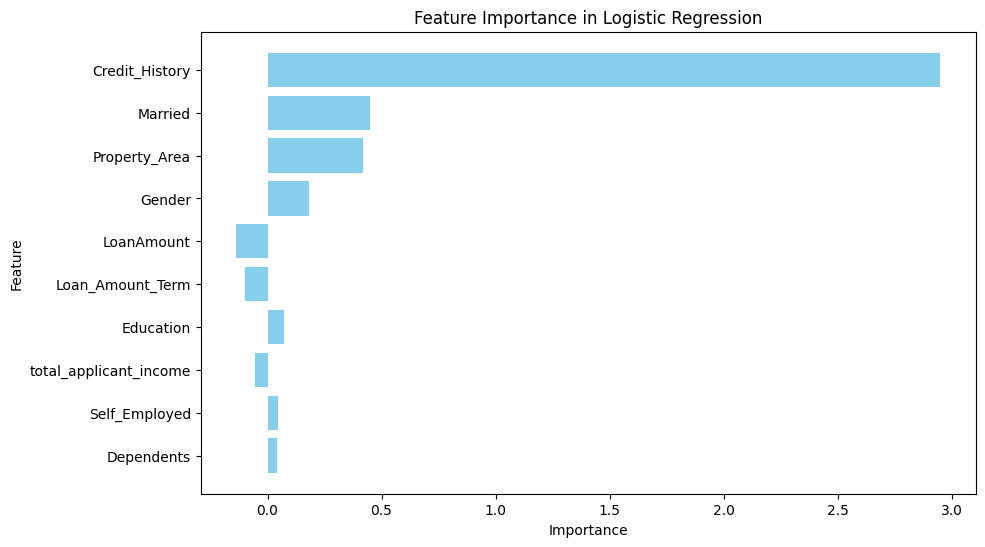

In [110]:
# Sort by absolute importance
feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(
    by='Abs_Importance', ascending=False)

# # Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'],
         feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

### Save The Model

Before we save our best model LogisticRegression for Production, we've to train our Model on the entire dataset with best parameters that we've just found.**

In [111]:
# Parameters for logistic regression
params = {'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(0.1)}

# Initialize logistic regression with the specified parameters
model = LogisticRegression(**params)
fin_model= model_val( model,X,y)

LogisticRegression(C=np.float64(0.1), penalty='l1', solver='liblinear') accuracy is 0.8828828828828829
LogisticRegression(C=np.float64(0.1), penalty='l1', solver='liblinear') Avg cross val score is 0.8066011466011467


In [80]:
import joblib

In [81]:


import pickle

# Save the trained model to a file using pickle
with open('loan_approval_final.pkl', 'wb') as file:
    pickle.dump(fin_model, file)

In [82]:
import pandas as pd

df = pd.DataFrame({
    'Gender': 1,
    'Married': 1,
    'Dependents': 2,
    'Education': 2,
    'Self_Employed': 0,
    'LoanAmount': 45,
    'Loan_Amount_Term': 180,
    'Credit_History': 1,
    'Property_Area': 1,
    'total_applicant_income':50000
}, index=[0])

In [83]:
result = fin_model.predict(df)

In [84]:
if result == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

Loan Not Approved
